# Partie 1 — Chargement et exploration
## 1.1 Chargement et constitution du corpus de titres


* Les imports

In [1]:
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

import spacy

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, LSTM, Bidirectional, TextVectorization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [2]:
"""
Ajout imposé par l'énoncé :
lemmatisation avec spaCy en anglais.
"""

nlp = spacy.load("en_core_web_sm")
print("Modèle spaCy chargé.")

Modèle spaCy chargé.


**Écrivez une fonction load_titles(filepath: str) -> pd.DataFrame qui :**

* Charge le fichier CSV
* Sélectionne et renomme les colonnes utiles : title → text, label → label
* Convertit les labels textuels en entiers : REAL → 1, FAKE → 0
* Supprime les lignes dont le titre est vide ou nul
* Affiche un résumé : nombre de titres par classe, proportion, longueur moyenne
* Sauvegardez le DataFrame résultant dans data/titles_clean.csv.

In [3]:


def load_titles(filepath: str) -> pd.DataFrame:

    # Chargement du fichier
    df = pd.read_csv(filepath)

    # Sélection des colonnes title et label
    df = df[["title", "label"]].copy()

    # Renommage de la colonne title en text (label est déja bien nommée)
    df = df.rename(columns={"title": "text"})

    # Remplace des Nan par une chaine vide
    df["text"] = df["text"].fillna("").astype(str).str.strip()
    
    # Récuperation uniquement des colonnes text non vide
    df = df[df["text"] != ""].copy()

    # Convertit les labels textuels en entiers : REAL → 1, FAKE → 0 
    df["label"] = df["label"].map({"REAL": 1, "FAKE": 0})

    # Création d'une colonne nb_tokens qui contient le nombre de mots du texte
    df["nb_tokens"] = df["text"].apply(lambda x: len(str(x).split()))

    # Affichage de la distribution de la classe label 
    print("Nombre de titres par classe :")
    print(df["label"].value_counts())

    # Affcihage des proportions
    print("\nProportions :")
    vcn = df["label"].value_counts(normalize=True)
    
    pct_real = round(vcn.loc[1], 4) * 100
    pct_fake = round(vcn.loc[0], 4) * 100

    print(f"Pourcentage de news REAL : {pct_real}%")
    print(f"Pourcentage de news FAKE : {pct_fake}%")

    print("\nLongueur moyenne des titres :", int(df["nb_tokens"].mean()), "mots")

    df.to_csv("../data/titles_clean.csv", index=False)

    return df

df = load_titles("../data/news.csv")
print(df.head())

Nombre de titres par classe :
label
1    3171
0    3164
Name: count, dtype: int64

Proportions :
Pourcentage de news REAL : 50.06%
Pourcentage de news FAKE : 49.94%

Longueur moyenne des titres : 10 mots
                                                text  label  nb_tokens
0                       You Can Smell Hillary’s Fear      0          5
1  Watch The Exact Moment Paul Ryan Committed Pol...      0         14
2        Kerry to go to Paris in gesture of sympathy      1          9
3  Bernie supporters on Twitter erupt in anger ag...      0         15
4   The Battle of New York: Why This Primary Matters      1          9


## 1.2 Analyse exploratoire

* Distribution des classes : le corpus est-il équilibré ? Si non, quelle stratégie envisagez-vous ?

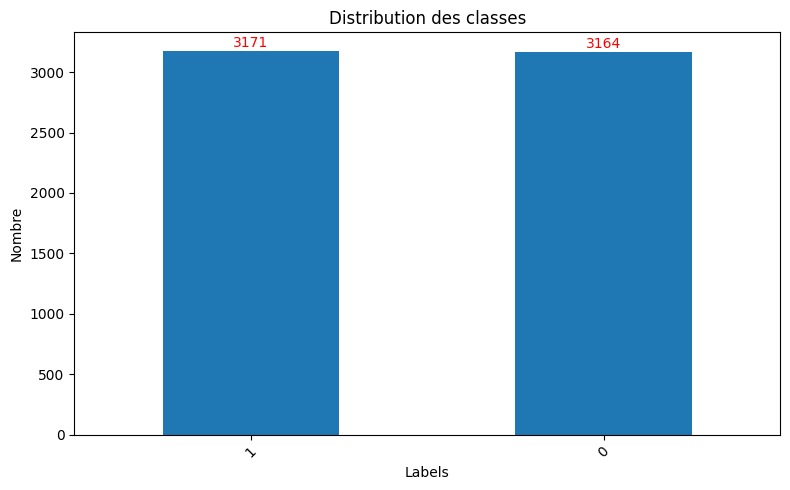

In [4]:
counts = df["label"].value_counts()

plt.figure(figsize=(8, 5))
ax = counts.plot(kind="bar")
ax.set_xlabel("Labels")
ax.tick_params(axis='x', rotation=45)
ax.set_ylabel("Nombre")
ax.set_title("Distribution des classes")
ax.bar_label(ax.containers[0], padding=1,color="red")
plt.tight_layout()
plt.show()

**=> On peut considérer que le corpus est équilibré avec 50.06% de REAL et 49.94% de FAKE**  

* Distribution de la longueur des titres en tokens : histogramme par classe, valeurs min / max / médiane

REAL
----------
Le nombre minimum de mots par titre : 2
Le nombre maximum de mots par titre : 27
La médiane de mots par titre : 10
FAKE
----------
Le nombre minimum des mots par titre : 1
Le nombre maximum des mots par titre : 53
La médiane des mots par titre : 11


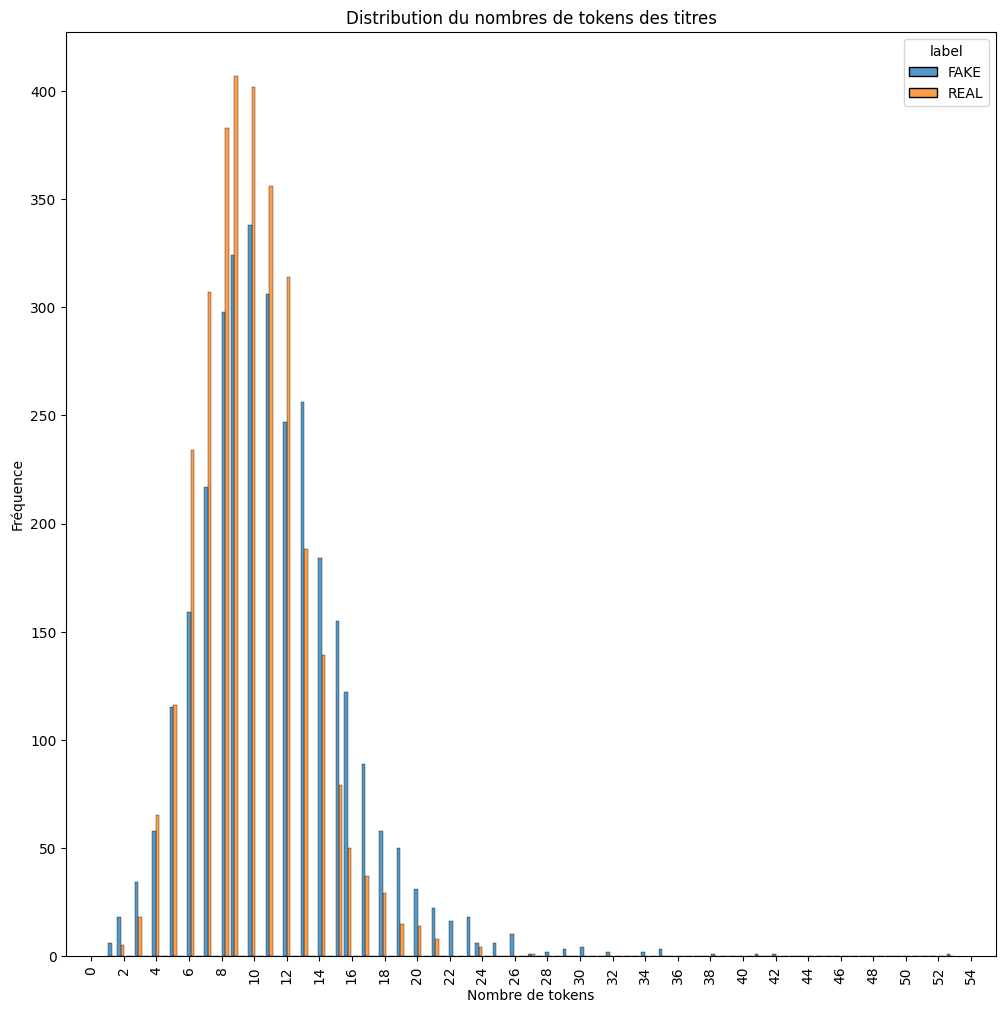

In [5]:
real_nb_tokens = df[df["label"] == 1]["nb_tokens"]
fake_nb_tokens = df[df["label"] == 0]["nb_tokens"]

# Affichage pour les titres REAL
print("REAL")
print("-"*10)
print(f"Le nombre minimum de mots par titre : {real_nb_tokens.min()}")
print(f"Le nombre maximum de mots par titre : {real_nb_tokens.max()}")
print(f"La médiane de mots par titre : {int(real_nb_tokens.median())}")

print("=" * 30) # Ligne de séparation

# Affichage pour les titres FAKE
print("FAKE")
print("-"*10)
print(f"Le nombre minimum des mots par titre : {fake_nb_tokens.min()}")
print(f"Le nombre maximum des mots par titre : {fake_nb_tokens.max()}")
print(f"La médiane des mots par titre : {int(fake_nb_tokens.median())}")

# plt.figure(figsize=(10, 5))
# plt.hist(fake_nb_tokens, bins=30, alpha=0.7, label="FAKE")
# plt.hist(real_nb_tokens, bins=30, alpha=0.7, label="REAL")
# plt.xticks(np.arange(0, 56, 2), rotation=45)
# plt.title("Distribution du nombres de tokens des titres")
# plt.xlabel("Nombre de tokens")
# plt.ylabel("Fréquence")
# plt.legend()
# plt.show()

import seaborn as sns
legend_map = {1: "REAL", 0: "FAKE"}
plt.figure(figsize=(12, 12))
sns.histplot(data=df, x='nb_tokens', hue=df['label'].map(legend_map), multiple="dodge", shrink=0.8)
# On garde tes graduations précises
plt.xticks(np.arange(0, 56, 2), rotation=90)
plt.title("Distribution du nombres de tokens des titres")
plt.xlabel("Nombre de tokens")
plt.ylabel("Fréquence")

plt.show()

**=> On observe qu'au delà de 27 tokens dans le titres, il y a une forte probabilité d'être sur une FAKE news. Par contre, on**
**observe également que les titres FAKE et REAL sont concentrés entre 4 et 16 tokens en majorité. La longueur ne suffit pas**
**pour déterminer si on a affaire à un titre FAKE ou REAL**

* Top 20 des tokens les plus fréquents dans chaque classe — affichez deux diagrammes en barres côte à côte

Top 20 REAL :
[('to', 724), ('the', 635), ('in', 500), ('Trump', 432), ('of', 392), ('for', 332), ('The', 319), ('a', 299), ('on', 293), ('Clinton', 285), ('and', 282), ('is', 254), ('GOP', 213), ('Obama', 193), ('Donald', 185), ('Hillary', 168), ('Why', 136), ('How', 118), ('2016', 114), ('House', 109)]

Top 20 FAKE :
[('The', 580), ('to', 559), ('the', 532), ('of', 472), ('in', 353), ('Trump', 348), ('To', 314), ('Hillary', 304), ('on', 296), ('and', 279), ('for', 262), ('Clinton', 250), ('a', 194), ('Is', 186), ('In', 185), ('by', 172), ('–', 171), ('-', 161), ('A', 159), ('Of', 152)]


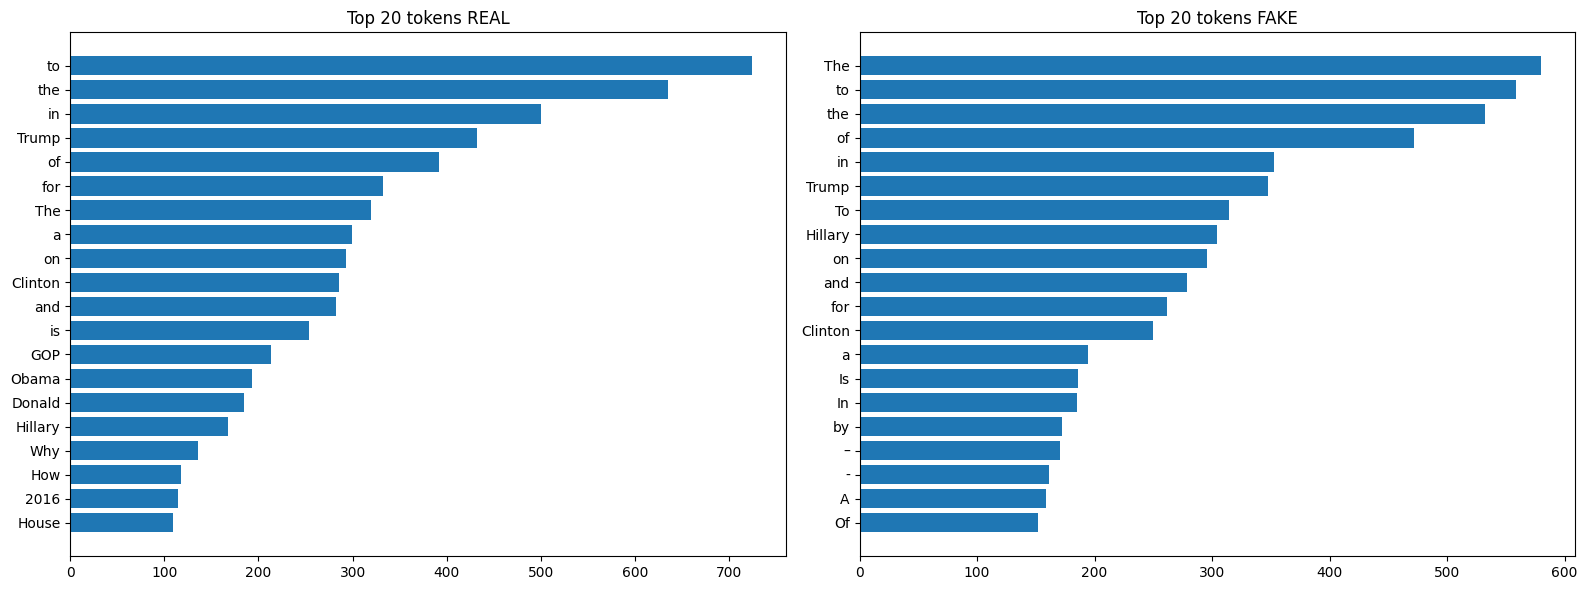

10 tokens discriminants REAL :
[('GOP', 199), ('to', 165), ('in', 147), ('Obama', 145), ('Donald', 106), ('a', 105), ('is', 105), ('the', 103), ('Sanders', 92), ('debate', 91)]

10 tokens discriminants FAKE :
[('The', 261), ('To', 226), ('–', 154), ('-', 141), ('Hillary', 136), ('by', 122), ('Comment', 104), ('Election', 101), ('Is', 99), ('Of', 97)]


In [6]:
df["tokens"] = df["text"].str.split()

def get_list_tokens(dataframe):
    list_tokens = []
    for list_words in dataframe["tokens"]:
        for word in list_words:
            list_tokens.append(word)
    return list_tokens

df_real = df[df["label"] == 1].copy()
df_fake = df[df["label"] == 0].copy()

list_tokens_real = get_list_tokens(df_real)
list_tokens_fake = get_list_tokens(df_fake)

list_occ_tokens_real = Counter(list_tokens_real)
list_occ_tokens_fake = Counter(list_tokens_fake)

print("Top 20 REAL :")
print(list_occ_tokens_real.most_common(20))

print("\nTop 20 FAKE :")
print(list_occ_tokens_fake.most_common(20))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

words_real, counts_real = zip(*list_occ_tokens_real.most_common(20))
axes[0].barh(words_real, counts_real)
axes[0].set_title("Top 20 tokens REAL")
axes[0].invert_yaxis()

words_fake, counts_fake = zip(*list_occ_tokens_fake.most_common(20))
axes[1].barh(words_fake, counts_fake)
axes[1].set_title("Top 20 tokens FAKE")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

list_discr_pur_real = list_occ_tokens_real - list_occ_tokens_fake
list_discr_pur_fake = list_occ_tokens_fake - list_occ_tokens_real

print("10 tokens discriminants REAL :")
print(list_discr_pur_real.most_common(10))

print("\n10 tokens discriminants FAKE :")
print(list_discr_pur_fake.most_common(10))

* Identification des tokens présents dans une seule classe (discriminants purs) : listez les 10 premiers par classe

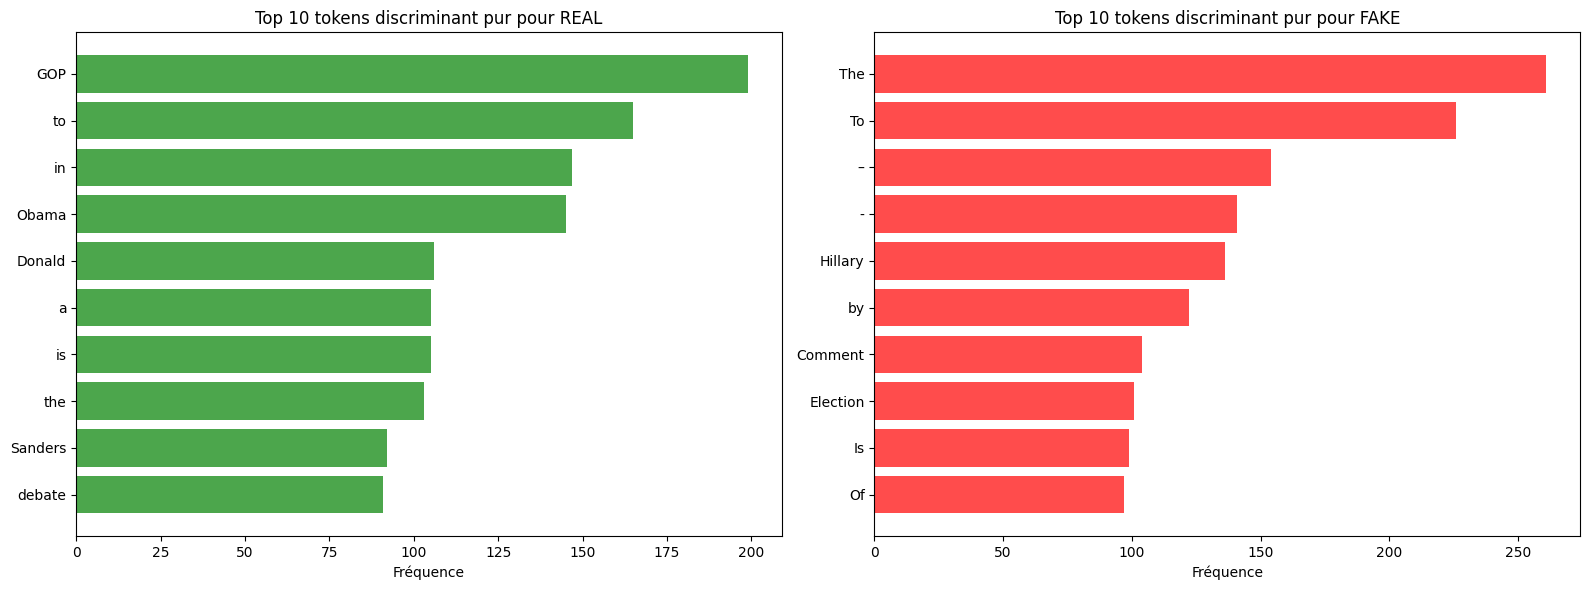

In [7]:
list_discr_pur_real = list_occ_tokens_real - list_occ_tokens_fake
list_discr_pur_fake = list_occ_tokens_fake - list_occ_tokens_real

# # Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 20 tokens real
words_pos, counts_pos = zip(*list_discr_pur_real.most_common(10))
axes[0].barh(words_pos, counts_pos, color='green', alpha=0.7)
axes[0].set_xlabel('Fréquence')
axes[0].set_title('Top 10 tokens discriminant pur pour REAL')
axes[0].invert_yaxis()

# 20 tokens fake
words_neg, counts_neg = zip(*list_discr_pur_fake.most_common(10))
axes[1].barh(words_neg, counts_neg, color='red', alpha=0.7)
axes[1].set_xlabel('Fréquence')
axes[1].set_title('Top 10 tokens discriminant pur pour FAKE')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

**=> On observe que malgré la volonté de ne garder que les discriminat pur pour chaque label, la casse des caractères laisse passer des tokens**
**identiques comme par exemple "The" et "the", "is" et Is" etc...** 

 **Identifiez au moins 3 titres potentiellement ambigus (ni clairement fiables, ni clairement trompeurs) et expliquez pourquoi ils posent problème**

1. "Kerry to go to Paris in gesture of sympathy" (REAL) :
        titre très neutre et informatif, sans marqueur émotionnel ou sensationnaliste. Il pourrait facilement être inventé car il manque de contexte, ce qui le rend difficile à classer.

2. "Bernie supporters on Twitter erupt in anger against the DNC: 'We tried to warn you!'" (REAL) :
       la présence de termes émotionnels comme "erupt" et "anger" peut faire penser à une fake news ou à un contenu biaisé, alors qu’il s’agit d’une réaction réelle. La frontière entre information et opinion est floue.

3. "Bernie Sanders Says He Will Not Be a Candidate in 2020" (FAKE) :
       le titre est formulé de manière factuelle et neutre, sans éléments sensationnalistes. Il peut facilement être perçu comme une information réelle, ce qui le rend ambigu.

**=> Ces titres posent problème car ils montrent que la détection de fake news ne dépend pas seulement de mots**
**sensationnalistes. Certains titres faux ressemblent à de vraies dépêches, tandis que certains titres réels emploient**
**un vocabulaire émotionnel ou polémique. La frontière entre REAL et FAKE n’est donc pas toujours visible uniquement dans**
**la forme du titre.**

# Partie 2 — Nettoyage et prétraitement
## 2.1 Pipeline de nettoyage

In [8]:
# implémentez un dictionnaire d'au moins 20 contractions courantes
contractions_dict = {
    "isn't": "is not",
    "aren't": "are not",
    "can't": "cannot",
    "can't've": "cannot have",
    "couldn't": "could not",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he would",
    "he'll": "he will",
    "he's": "he is",
    "i'm": "i am",
    "i've": "i have",
    "it's": "it is",
    "let's": "let us",
    "shouldn't": "should not",
    "won't": "will not",
    "wouldn't": "would not"
}

def clean_title(text: str) -> str:
    # Mise en minuscules
    text = text.lower()

    # Suppression des URLs et des mentions de type @username
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"[^a-z0-9\s']", " ", text)
    
    # Suppression de la ponctuation et des chiffres isolés
    text = re.sub(r"\b\d+\b", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    # Expansion des contractions anglaises (don't → do not, isn't → is not, etc.)
    # temp_text = []
    # for word in text.split():
    #     if word in contractions_dict:
    #         temp_text.extend(contractions_dict[word].split())
    #     else:
    #         temp_text.append(word)

    # stop_words = set(stopwords.words("english"))
    # negations = {"not", "no", "never", "neither"}

    # words_filtered = []
    # for word in temp_text:
    #     if word in negations or word not in stop_words:
    #         words_filtered.append(word)

    temp_text = []
    split_text = text.split()
    for word in split_text :
        if word in contractions_dict :
            temp_text.append(contractions_dict[word])
        else :
            temp_text.append(word)
    
    text = " ".join(temp_text)

    # Supprimer les stopwords sauf "not", "no", "never", "neither"
    stop_words = set(stopwords.words('english'))
    words_filtered = []
    for word in text.split() :
        if word in ["not", "no", "never", "neither"] or word not in stop_words :
            words_filtered.append(word)

    # Lemmatisation avec spaCy (modèle en_core_web_sm)
    doc = nlp(" ".join(words_filtered))
    lemmas = [token.lemma_ for token in doc if len(token.lemma_) >= 2]

    return " ".join(lemmas)

print(clean_title("I'd like to don't work because i bought a new z skateboard"))

like not work buy new skateboard


 
La conservation des mots de négation est essentielle car supprimer des termes comme *not*, *no* ou *never* peut inverser complètement le sens d’un titre. Dans un contexte de détection de désinformation, cela peut conduire le modèle à apprendre une version erronée de l’information.

Exemples tirés du corpus :
1. **"Bernie Sanders Says He Will Not Be a Candidate in 2020"** : si l’on supprime *not*, le titre devient l’inverse de l’information initiale.
2. **"Donald Trump Is Changing His Campaign Slogan to Prove He’s Not Racist"** : supprimer *not* transformerait le sens du titre en affirmant qu’il est raciste, ce qui modifie totalement l’interprétation.

In [9]:
df["text_clean"] = df["text"].apply(clean_title)
df = df[df["text_clean"].str.strip() != ""].copy()
print(df[["text","text_clean"]].head(5))

                                                text  \
0                       You Can Smell Hillary’s Fear   
1  Watch The Exact Moment Paul Ryan Committed Pol...   
2        Kerry to go to Paris in gesture of sympathy   
3  Bernie supporters on Twitter erupt in anger ag...   
4   The Battle of New York: Why This Primary Matters   

                                          text_clean  
0                                 smell hillary fear  
1  watch exact moment paul ryan commit political ...  
2                    kerry go paris gesture sympathy  
3  bernie supporter twitter erupt anger dnc we tr...  
4                     battle new york primary matter  


## 2.2 Mesure de l'impact du nettoyage




Question écrite : Pourquoi la conservation des mots de négation est-elle particulièrement importante dans un contexte de détection de désinformation ? Donnez deux exemples concrets tirés du corpus.

* La taille du vocabulaire avant et après nettoyage

In [10]:
vocab_before = set(" ".join(df["text"].str.lower()).split())
vocab_after = set(" ".join(df["text_clean"]).split())

nb_vocab_before = len(vocab_before)
nb_vocab_after = len(vocab_after)
print("Taille vocabulaire avant nettoyage :", nb_vocab_before )
print("Taille vocabulaire après nettoyage :", nb_vocab_after)
print()
print(f"Après nettoyage, le vocabulaire a diminué de {round((1- nb_vocab_after/nb_vocab_before)*100,2)}%")

Taille vocabulaire avant nettoyage : 14449
Taille vocabulaire après nettoyage : 7848

Après nettoyage, le vocabulaire a diminué de 45.68%


* Le nombre de titres devenus vides après nettoyage : comment les gérez-vous ?

In [11]:
df["tokens_clean"] = df["text_clean"].str.split()
df["nb_tokens_clean"] = df["tokens_clean"].str.len()

print(df[df["nb_tokens_clean"]==0])

print("Nombre de titres vides après nettoyage :", (df["nb_tokens_clean"] == 0).sum())

df = df[df["nb_tokens_clean"] != 0].copy()

Empty DataFrame
Columns: [text, label, nb_tokens, tokens, text_clean, tokens_clean, nb_tokens_clean]
Index: []
Nombre de titres vides après nettoyage : 0


**=> On décidera de retirer les titres ayant une liste de tokens vide pour éviter des traitements inutiles et les erreurs** 


* La réduction moyenne de la longueur des titres (en tokens)

In [12]:

print(df[["tokens","nb_tokens","tokens_clean","nb_tokens_clean"]].head(5))
avg_reduction_length = (df["nb_tokens"] - df["nb_tokens_clean"]).mean()
print()
print("=> Réduction moyenne de la longueur des titres :", int(avg_reduction_length))



                                              tokens  nb_tokens  \
0                 [You, Can, Smell, Hillary’s, Fear]          5   
1  [Watch, The, Exact, Moment, Paul, Ryan, Commit...         14   
2  [Kerry, to, go, to, Paris, in, gesture, of, sy...          9   
3  [Bernie, supporters, on, Twitter, erupt, in, a...         15   
4  [The, Battle, of, New, York:, Why, This, Prima...          9   

                                        tokens_clean  nb_tokens_clean  
0                             [smell, hillary, fear]                3  
1  [watch, exact, moment, paul, ryan, commit, pol...               11  
2              [kerry, go, paris, gesture, sympathy]                5  
3  [bernie, supporter, twitter, erupt, anger, dnc...                9  
4               [battle, new, york, primary, matter]                5  

=> Réduction moyenne de la longueur des titres : 3


# Partie 3 — Représentation vectorielle
## 3.1 Vectorisation TF-IDF


**Transformez les titres nettoyés en vecteurs numériques avec TfidfVectorizer de scikit-learn.**

* Paramètres à utiliser :

TfidfVectorizer(
    max_features=3000,
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2),
    sublinear_tf=True
)
* Découpez le corpus en train (80 %) et test (20 %) avec stratification sur les labels et random_state=42
* Entraînez le vectoriseur uniquement sur le train, transformez train et test séparément
* Sauvegardez le vectoriseur avec joblib

In [13]:
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    df["text_clean"],
    df["label"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df["label"]
)

tfidf = TfidfVectorizer(
    max_features=3000,
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train_clean).toarray()
X_test_tfidf = tfidf.transform(X_test_clean).toarray()

print("Shape train TF-IDF :", X_train_tfidf.shape)
print("Shape test TF-IDF :", X_test_tfidf.shape)

joblib.dump(tfidf, "../models/vectorizer.pkl")

Shape train TF-IDF : (5066, 3000)
Shape test TF-IDF : (1267, 3000)


['../models/vectorizer.pkl']

## 3.2 Embedding avec TensorFlow
**En parallèle du TF-IDF, préparez une seconde représentation basée sur des embeddings appris :**

* Utilisez tf.keras.layers.TextVectorization pour construire un vocabulaire d'index à partir des titres bruts (non lemmatisés)
* Fixez max_tokens=5000 et output_sequence_length=30 (padding/truncation)
* Cette couche sera intégrée directement dans les modèles de la Partie 4
* Question écrite : Quelle différence fondamentale y a-t-il entre un vecteur TF-IDF et un vecteur d'embedding appris ? Laquelle de ces deux représentations est capable de capturer que misleading et deceptive sont sémantiquement proches ? Justifiez.

In [14]:
# --------------------------------------------------------

# creation d'une colonne text_raw_emb suite à des problèmes avec certains caractères dans le texte (caractères cyrilliques par exemple)

import unicodedata 

df["text_raw_emb"] = (
    df["text"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
)

def normalize(text: str) -> str:
    return unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8")

df["text_raw_emb"] = df["text_raw_emb"].apply(normalize)
#------------------------------------------------------------

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    df["text_raw_emb"],
    df["label"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df["label"]
)

text_vectorizer = TextVectorization(
    max_tokens=5000,
    output_sequence_length=30,
    standardize="lower_and_strip_punctuation"
)

text_vectorizer.adapt(X_train_raw.to_numpy())

print("Taille vocabulaire TextVectorization :", len(text_vectorizer.get_vocabulary()))


Taille vocabulaire TextVectorization : 5000


**=> Le TF-IDF traite chaque mot de manière isolé (sans lien avec les autres), alors que l'embedding**
**place mathématiquement les mots aux sens proches côte à côte.**
**Pour l'embedding misleading et deceptive sont synonymes car il apprend qu'ils sont utilisés dans les mêmes contextes**
**contrairement au TF-IDF qui ne voit que deux étiquettes différentes.**

# Partie 4 — Modélisation
## 4.1 Modèle baseline — réseau dense sur TF-IDF
**Construisez un premier modèle avec l'API Sequential de TensorFlow, prenant en entrée les vecteurs TF-IDF :**

**Architecture minimale :**

* Dense(256, activation='relu')
* Dropout(0.4)
* Dense(128, activation='relu')
* Dropout(0.3)
* Dense(1, activation='sigmoid')
* Compilez avec optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']
* Entraînez sur 30 epochs avec validation_split=0.15

**Utilisez les callbacks suivants :**
* EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss')
* ModelCheckpoint pour sauvegarder le meilleur modèle

**Tracez les courbes de loss et d'accuracy (train vs validation)**

In [15]:
import time 

early_stop_dense = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint_dense = ModelCheckpoint(
    "../models/best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

model_dense = Sequential([
    Dense(256, activation="relu", input_shape=(X_train_tfidf.shape[1],)),
    Dropout(0.4),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model_dense.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

start_dense = time.time()

history_dense = model_dense.fit(
    X_train_tfidf,
    y_train_clean,
    validation_split=0.15,
    epochs=30,
    callbacks=[early_stop_dense, checkpoint_dense],
    verbose=1
)
dense_train_time = time.time() - start_dense
print(f"Temps d'entraînement Dense : {dense_train_time:.2f} s")

Epoch 1/30


c:\M2i\ECF-4 Ikhadriouene Farid\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


134/135 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5971 - loss: 0.6642
Epoch 1: val_loss improved from None to 0.45729, saving model to ../models/best_model.keras

Epoch 1: finished saving model to ../models/best_model.keras
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6981 - loss: 0.5929 - val_accuracy: 0.7987 - val_loss: 0.4573
Epoch 2/30
132/135 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8343 - loss: 0.3666
Epoch 2: val_loss did not improve from 0.45729
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8655 - loss: 0.3154 - val_accuracy: 0.8000 - val_loss: 0.5001
Epoch 3/30
132/135 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9148 - loss: 0.2102
Epoch 3: val_loss did not improve from 0.45729
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9264 - loss: 0.1860 - val_accuracy: 0.7908 - val_loss: 0.5864
Epoch 4/30
131/135 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9599 - loss: 0.1200
Epoch 4: val_loss did not improve from 0.45729
135/135 ━━━━━━━━━━━━

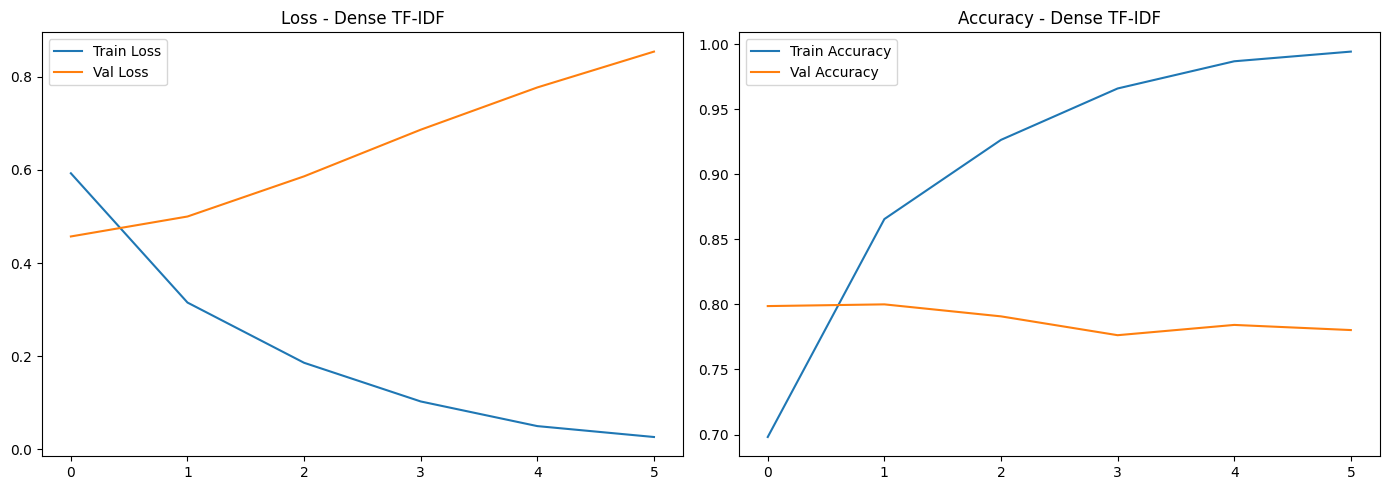

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_dense.history["loss"], label="Train Loss")
axes[0].plot(history_dense.history["val_loss"], label="Val Loss")
axes[0].set_title("Loss - Dense TF-IDF")
axes[0].legend()

axes[1].plot(history_dense.history["accuracy"], label="Train Accuracy")
axes[1].plot(history_dense.history["val_accuracy"], label="Val Accuracy")
axes[1].set_title("Accuracy - Dense TF-IDF")
axes[1].legend()

plt.tight_layout()
plt.show()

# 4.2 Modèle avec embeddings appris — architecture séquentielle
**Construisez un second modèle intégrant la couche TextVectorization et une couche Embedding :**

**Architecture :**

* TextVectorization (vocab_size=5000, sequence_length=30)
* Embedding(input_dim=5000, output_dim=64, mask_zero=True)
* Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2))
* Dense(64, activation='relu')
* Dropout(0.3)
* Dense(1, activation='sigmoid')
* Même configuration de compilation et de callbacks que le modèle 4.1
* Entraînez sur 30 epochs
* Tracez les courbes d'apprentissage

In [17]:
early_stop_bilstm = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint_bilstm = ModelCheckpoint(
    "../models/best_model_bilstm.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

callbacks=[early_stop_bilstm, checkpoint_bilstm]

model_bilstm = Sequential([
    keras.Input(shape=(1,), dtype=tf.string),
    text_vectorizer,
    Embedding(input_dim=5000, output_dim=64, mask_zero=True),
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model_bilstm.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Conversion explicite en tenseurs TensorFlow (conforme au moteur Keras/Optree)
X_train_raw_tensor = tf.convert_to_tensor(X_train_raw.values, dtype=tf.string)
y_train_raw_tensor = tf.convert_to_tensor(y_train_raw.values, dtype=tf.int32)

start_bilstm = time.time()

# Lancement de l'entraînement avec les tenseurs
history_bilstm = model_bilstm.fit(
    X_train_raw_tensor,
    y_train_raw_tensor,
    validation_split=0.15,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)

bilstm_train_time = time.time() - start_bilstm
print(f"Temps d'entraînement BiLSTM : {bilstm_train_time:.2f} s")

Epoch 1/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6086 - loss: 0.6414
Epoch 1: val_loss improved from None to 0.47377, saving model to ../models/best_model_bilstm.keras

Epoch 1: finished saving model to ../models/best_model_bilstm.keras
135/135 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.6986 - loss: 0.5631 - val_accuracy: 0.7750 - val_loss: 0.4738
Epoch 2/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8579 - loss: 0.3417
Epoch 2: val_loss did not improve from 0.47377
135/135 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.8850 - loss: 0.2854 - val_accuracy: 0.8105 - val_loss: 0.4760
Epoch 3/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9288 - loss: 0.2013
Epoch 3: val_loss did not improve from 0.47377
135/135 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9403 - loss: 0.1642 - val_accuracy: 0.7895 - val_loss: 0.6377
Epoch 4/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9578 - loss: 0.1208
Epoch 4: val_loss did not improve f

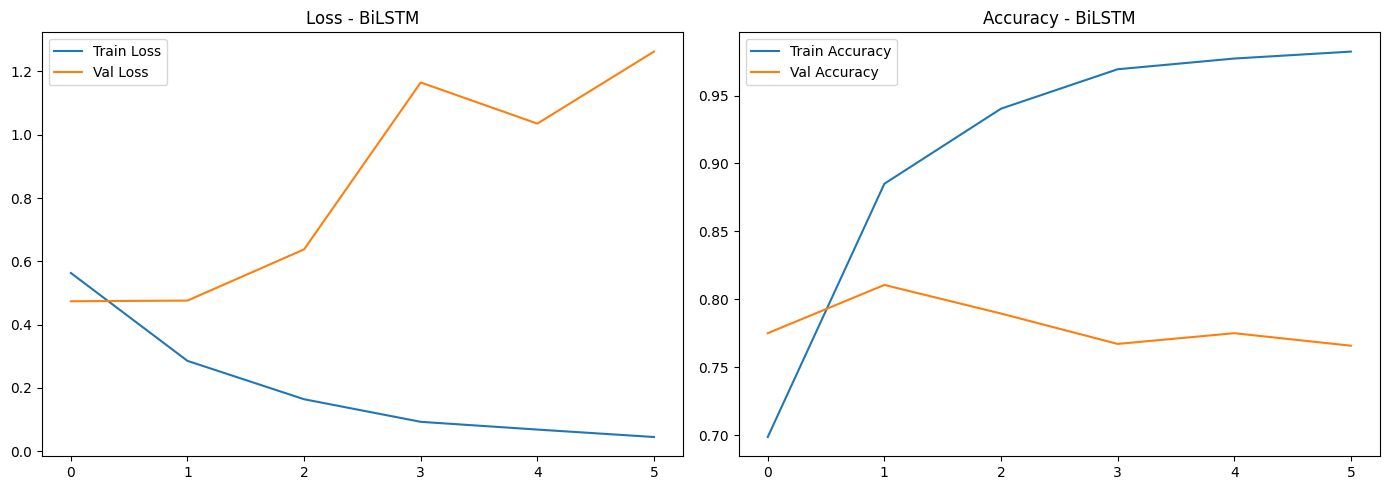

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_bilstm.history["loss"], label="Train Loss")
axes[0].plot(history_bilstm.history["val_loss"], label="Val Loss")
axes[0].set_title("Loss - BiLSTM")
axes[0].legend()

axes[1].plot(history_bilstm.history["accuracy"], label="Train Accuracy")
axes[1].plot(history_bilstm.history["val_accuracy"], label="Val Accuracy")
axes[1].set_title("Accuracy - BiLSTM")
axes[1].legend()

plt.tight_layout()
plt.show()

# 4.3 Comparaison des deux architectures
**Remplissez le tableau suivant avec vos résultats mesurés sur l'ensemble de test :**

* Critère	Modèle Dense (TF-IDF)	Modèle LSTM Bidirectionnel
* Accuracy (test)		
* Precision — classe FAKE		
* Recall — classe FAKE		
* F1-score (macro)		
* AUC-ROC		
* Epochs effectifs (EarlyStopping)		
* Nombre de paramètres entraînables		
* Temps d'entraînement (approx.)		
* Question écrite : Lequel des deux modèles recommanderiez-vous pour une mise en production ? Justifiez votre choix en tenant compte à la fois des performances et des contraintes opérationnelles (temps de réponse, maintenance, volume de données).

In [19]:
y_proba_dense = model_dense.predict(X_test_tfidf, verbose=0).ravel()
y_pred_dense = (y_proba_dense >= 0.5).astype(int)

X_test_raw_array = X_test_raw.to_numpy(dtype=str)


# y_proba_bilstm = model_bilstm.predict(X_test_raw_array, verbose=0).ravel()
# y_pred_bilstm = (y_proba_bilstm >= 0.5).astype(int)

# Conversion en tenseur string pour satisfaire le moteur Keras/Optree
X_test_raw_tensor = tf.convert_to_tensor(X_test_raw.values, dtype=tf.string)

# Prédiction avec le tenseur
y_proba_bilstm = model_bilstm.predict(X_test_raw_tensor, verbose=0).ravel()
y_pred_bilstm = (y_proba_bilstm >= 0.5).astype(int)

dense_params = model_dense.count_params()
bilstm_params = model_bilstm.count_params()

# print("Nombre de paramètres Dense :", dense_params)
# print("Nombre de paramètres BiLSTM :", bilstm_params)

comparison_df = pd.DataFrame({
    "Critère": [
        "Accuracy (test)",
        "Precision — classe FAKE",
        "Recall — classe FAKE",
        "F1-score (macro)",
        "AUC-ROC",
        "Epochs effectifs",
        "Nombre de paramètres entraînables",
        "Temps d'entraînement (approx.)"
    ],
    "Modèle Dense (TF-IDF)": [
        accuracy_score(y_test_clean, y_pred_dense),
        precision_score(y_test_clean, y_pred_dense, pos_label=0),
        recall_score(y_test_clean, y_pred_dense, pos_label=0),
        f1_score(y_test_clean, y_pred_dense, average="macro"),
        roc_auc_score(y_test_clean, y_proba_dense),
        len(history_dense.history["loss"]),
        dense_params,
        f"{dense_train_time:.2f} s"
    ],
    "Modèle LSTM Bidirectionnel": [
        accuracy_score(y_test_raw, y_pred_bilstm),
        precision_score(y_test_raw, y_pred_bilstm, pos_label=0),
        recall_score(y_test_raw, y_pred_bilstm, pos_label=0),
        f1_score(y_test_raw, y_pred_bilstm, average="macro"),
        roc_auc_score(y_test_raw, y_proba_bilstm),
        len(history_bilstm.history["loss"]),
        bilstm_params,
        f"{bilstm_train_time:.2f} s"
    ]
})

print(comparison_df)

                             Critère Modèle Dense (TF-IDF)  \
0                    Accuracy (test)              0.803473   
1            Precision — classe FAKE              0.775072   
2               Recall — classe FAKE               0.85466   
3                   F1-score (macro)               0.80297   
4                            AUC-ROC              0.881996   
5                   Epochs effectifs                     6   
6  Nombre de paramètres entraînables                801281   
7     Temps d'entraînement (approx.)                8.23 s   

  Modèle LSTM Bidirectionnel  
0                   0.775848  
1                   0.710495  
2                    0.93049  
3                    0.77041  
4                   0.879571  
5                          6  
6                     394369  
7                    32.66 s  


**=> Le Modèle LSTM Bidirectionnel est techniquement plus sophistiqué et pourrait surpasser le modèle Dense avec un**
volume de données **beaucoup plus important (plusieurs centaines de milliers d'exemples). Cependant,**
**sur le volume de données actuel, le Modèle Dense offre le meilleur compromis : il est plus performant, plus rapide**
**et moins coûteux à héberger.**

# Partie 5 — Évaluation approfondie
## 5.1 Analyse des performances du meilleur modèle
**Sur l'ensemble de test, calculez et affichez pour votre meilleur modèle :**

* La matrice de confusion annotée (valeurs absolues + pourcentages)
* Le rapport de classification complet (precision, recall, F1 par classe)
* La courbe ROC avec l'AUC

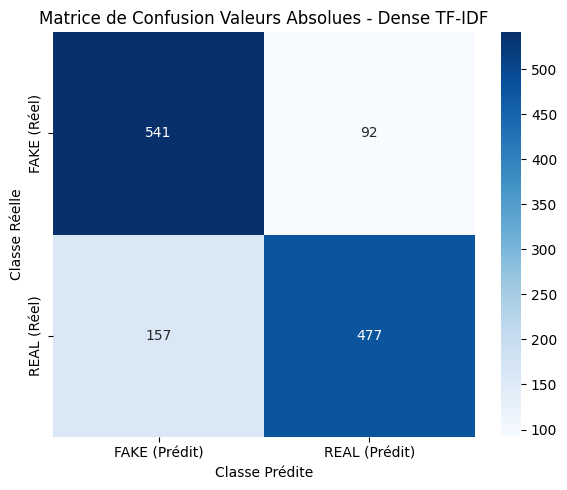

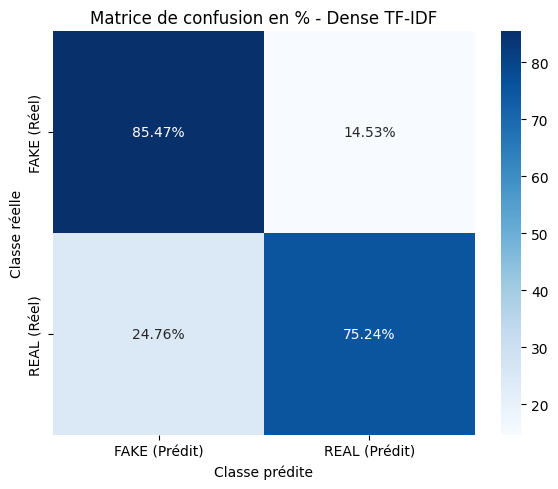


Rapport de classification :
              precision    recall  f1-score   support

        FAKE       0.78      0.85      0.81       633
        REAL       0.84      0.75      0.79       634

    accuracy                           0.80      1267
   macro avg       0.81      0.80      0.80      1267
weighted avg       0.81      0.80      0.80      1267



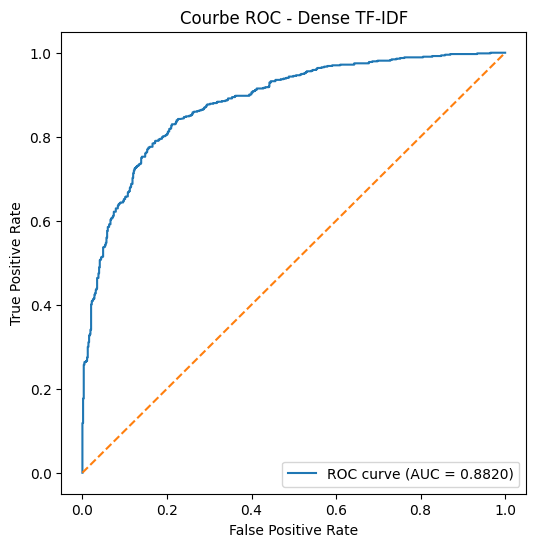

In [ ]:
best_model_name = "Dense TF-IDF"
best_y_true = y_test_clean
best_y_pred = y_pred_dense
best_y_proba = y_proba_dense
best_titles = X_test_clean.reset_index(drop=True)

cm = confusion_matrix(best_y_true, best_y_pred)
cm_percent = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

# print("Matrice de confusion :")
# print(cm)

# Création de la figure
plt.figure(figsize=(6, 5))
sns.heatmap(cm, 
            annot=True,          # Affiche les valeurs brutes dans les cases
            fmt="d",             # Format entier ("d" pour decimal)
            cmap="Blues",       # Couleur bleue dégradée
            xticklabels=["FAKE (Prédit)", "REAL (Prédit)"], 
            yticklabels=["FAKE (Réel)", "REAL (Réel)"])
plt.title(f"Matrice de Confusion Valeurs Absolues - {best_model_name}", fontsize=12)
plt.ylabel("Classe Réelle", fontsize=10)
plt.xlabel("Classe Prédite", fontsize=10)
plt.tight_layout()
plt.show()



# print("\nPourcentages :")
# print(np.round(cm_percent, 2))
#cm_percent_total = cm.astype(float) / cm.sum() * 100

labels = np.array([[f"{value:.2f}%" for value in row] for row in cm_percent])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_percent,
    annot=labels,
    fmt="",
    cmap="Blues",
    xticklabels=["FAKE (Prédit)", "REAL (Prédit)"],
    yticklabels=["FAKE (Réel)", "REAL (Réel)"]
)

plt.title(f"Matrice de confusion en % - {best_model_name}", fontsize=12)
plt.ylabel("Classe réelle", fontsize=10)
plt.xlabel("Classe prédite", fontsize=10)
plt.tight_layout()
plt.show()


print("\nRapport de classification :")
print(classification_report(best_y_true, best_y_pred, target_names=["FAKE", "REAL"]))

fpr, tpr, thresholds = roc_curve(best_y_true, best_y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Courbe ROC - {best_model_name}")
plt.legend(loc="lower right")
plt.show()

# 5.2 Analyse des erreurs


In [21]:
results_df = pd.DataFrame({
    "text_raw": X_test_clean.reset_index(drop=True),
    "label_true": best_y_true.to_numpy(dtype="int32"),
    "label_pred": best_y_pred,
    "score_real": best_y_proba
})

false_positives = results_df[(results_df["label_true"] == 0) & (results_df["label_pred"] == 1)].copy()
false_negatives = results_df[(results_df["label_true"] == 1) & (results_df["label_pred"] == 0)].copy()

# false_positives["confidence_fake"] = 1 - false_positives["score_real"]
# false_negatives["confidence_real"] = false_negatives["score_real"]

false_positives["confidence_real"] = false_positives["score_real"]
false_negatives["confidence_fake"] = 1 - false_negatives["score_real"]

# false_positives = false_positives.sort_values("confidence_fake", ascending=False).head(15)
# false_negatives = false_negatives.sort_values("confidence_real", ascending=False).head(15)

false_positives = false_positives.sort_values("confidence_real", ascending=False).head(15)
false_negatives = false_negatives.sort_values("confidence_fake", ascending=False).head(15)

* Les 15 faux positifs (titres REAL classifiés FAKE) ayant le score de confiance le plus élevé

In [ ]:
print(false_positives[["text_raw", "confidence_real"]])


15 faux positifs :
                                               text_raw  confidence_real
127   noun verb donald trump rubio seeks seize murph...         0.964694
1248  awesome video show real donald trump president...         0.952945
1163                  erdogan check obama bombing syria         0.931673
1227  plan parenthood abortion pill usage rival surgery         0.928867
247   look paul ryan masochist paul nehlen gun house...         0.928491
340   washington 's embargo cuba not effective isola...         0.927425
838   green party margaret flower challenge we senat...         0.925295
991   comment circulate republican presidential cand...         0.922059
553   break irrefutable proof obama lie protect hill...         0.915644
1184        saudis foil isis terror attack pack stadium         0.910970
1185  iowa farmer claim bill clinton sex cow cocaine...         0.906280
781                       iran finland sign mous tehran         0.904161
769   peaceful sincerely grace p

* Les 15 faux négatifs (titres FAKE classifiés REAL) ayant le score de confiance le plus élevé

In [ ]:
print(false_negatives[["text_raw", "confidence_fake"]])

15 faux négatifs :
                                               text_raw  confidence_fake
464                 trump warning rig election credible         0.976503
6     page hack wikileak email teach we hillary clinton         0.966572
117                                    no not world war         0.953357
116   america simple ideology one russia 's top us e...         0.950476
858   haywire hack medium refuse believe trump 's ru...         0.949027
423                       trump new rig system election         0.943128
201   trump lose cheating ask supporter watch pollin...         0.938315
397   reveal interview trump predict massive recessi...         0.930905
931   clinton foundation continue accept foreign mon...         0.928159
74    saudi arabia 's king abdullah incremental refo...         0.925670
1085            hillary supporter excite also practical         0.923029
166                                   life among berned         0.921656
505          russian passenger p

## 5.3 Robustesse
Testez le comportement du meilleur modèle sur les 10 titres suivants, que vous n'avez pas vus pendant l'entraînement. Affichez pour chacun la classe prédite et le score de confiance :

1. "Scientists discover new treatment for common disease"
2. "SHOCKING: Government hiding truth about water supply"
3. "Local elections results announced in three counties"
4. "You won't believe what this celebrity did last night"
5. "Central bank raises interest rates by 0.25 points"
6. "This one weird trick cures all allergies naturally"
7. "Parliament votes on new environmental legislation"
8. "Doctors don't want you to know this secret remedy"
9. "Tech company reports quarterly earnings below forecast"
10. "EXCLUSIVE: Famous actor reveals hidden agenda of elites"
Commentez : les prédictions vous semblent-elles cohérentes ? Y a-t-il des titres pour lesquels le modèle se trompe manifestement ou hésite ?

In [24]:
robust_titles = [
    "Scientists discover new treatment for common disease",
    "SHOCKING: Government hiding truth about water supply",
    "Local elections results announced in three counties",
    "You won't believe what this celebrity did last night",
    "Central bank raises interest rates by 0.25 points",
    "This one weird trick cures all allergies naturally",
    "Parliament votes on new environmental legislation",
    "Doctors don't want you to know this secret remedy",
    "Tech company reports quarterly earnings below forecast",
    "EXCLUSIVE: Famous actor reveals hidden agenda of elites"
]

robust_titles_clean = [clean_title(title) for title in robust_titles]
robust_vectors = tfidf.transform(robust_titles_clean).toarray()

robust_probs = model_dense.predict(robust_vectors, verbose=0).ravel()
robust_preds = (robust_probs >= 0.5).astype(int)

robust_df = pd.DataFrame({
    "title": robust_titles,
    "label": ["REAL" if x == 1 else "FAKE" for x in robust_preds],
    "confidence_real": np.round(robust_probs, 4)
})

robust_df

,title,label,confidence_real
0,Scientists discover new treatment for common d...,FAKE,0.2048
1,SHOCKING: Government hiding truth about water ...,FAKE,0.0595
2,Local elections results announced in three cou...,FAKE,0.2886
3,You won't believe what this celebrity did last...,REAL,0.7066
4,Central bank raises interest rates by 0.25 points,FAKE,0.2720
5,This one weird trick cures all allergies natur...,FAKE,0.1316
6,Parliament votes on new environmental legislation,FAKE,0.2004
7,Doctors don't want you to know this secret remedy,FAKE,0.2124
8,Tech company reports quarterly earnings below ...,FAKE,0.1871
9,EXCLUSIVE: Famous actor reveals hidden agenda ...,FAKE,0.2127


**=> Les prédictions du modèle sont globalement cohérentes pour les titres très sensationnalistes ou complotistes, qu’il classe** **majoritairement comme FAKE. Cependant, plusieurs titres au ton neutre et informatif (scientifique, politique ou économique)**
**sont également classés comme FAKE, ce qui suggère des erreurs de classification. Le modèle semble donc s’appuyer fortement sur**
**des indices lexicaux superficiels et généraliser de manière excessive. Certains cas présentent en outre des scores de confiance** **modérés, indiquant une certaine hésitation. Globalement, le modèle capture bien certains patterns de fake news, mais manque de** **robustesse sur des titres plus factuels.**